# Discrete event simulation: Cost-effectiveness of MIPAC Units compared to hospitals in Norway

This notebook implements a discrete event simulation to estimate the cost-effectiveness of treating acute care patients in Municipal Inpatient Acute Care Units (MIPACs) in Norway comapred to hospitals from a healthcare persepctive in Norway

The model used parameters based on data from Norwegian Health Directorate, Statistics Norway and National Patient Registry. The model has four different archetypes based on the data available and simulates admissions, length of stay, capacity constraints, costs and effects.


## The purpose of the model is to:
- Simulate arrival of patients to MIPAC units over one year period
- Model varying referral proportions of GPs to MIPAC units
- Account for limited capacity in MIPAC assuming no waiting
- Route the overflow of patients to hospitals
- Estimate the length of stay of patients, costs and effects

## Simulation overview

    - Time horizon: 730 days
    - Warm up period: 365 days
    - Distribution used for arrival process: Exponential 
    - Distribution used for los: log-normal 
    - Unit of analysis: Individual patients
    - Output: Patient-level cost and functional improvement; others- LOS and pathway 
    - A fixed random seed set for ensuring reproducibility

## Care pathways

Patients follow one of three pathways:
1. MIPAC admission
   -Patient who is suitable for MIPAC
3. Hospital admission when the MIPAC beds are fully occupied
4. Direct hopsital admission for othe reasons than full occupancy


## Key assumptions

1.	All the patients in the model are assumed to be appropriate MIPAC patients.
2.	Patients do not wait for MIPAC beds i.e. they are immediately referred to hospital if there is no bed available. This was done to reflect reality where there is no negotiation on if the beds will be available in a few hours or so. 
3.	Hospital capacity is assumed to be unlimited. This is to reflect the absence of alternatives and obligation of hospitals to accept the patients in need of acute care even when they are full.
4.	Referral rate to MIPACs is assumed to be 70%. The difference in referral probabilities between GP office and OOH GP service not taken into account in the main model. 
5.	No seasonal patterns of admissions in MIPAC has been accounted for in the model. 
6.	Variations like intermunicipal collaboration and geography has not been taken into account in the main model for simplicity. 
7. Length of stay follows a lognormal distribution 

In [57]:
import simpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


In [58]:

# GLOBAL PARAMETERS
# ============================================================

seed = 1234

sim_duration = 730       # days
warmup = 365             # days

# HOSPITAL PARAMETERS
# ============================================================

cost_epi_h = 60681

qaly_h = 0.70

mean_los_h = 2.5
sd_los_h = 1.5

sig2_h = np.log(1 + (sd_los_h**2 / mean_los_h**2))

sig_los_h = np.sqrt(sig2_h)

mu_los_h = (    np.log(mean_los_h)    - 0.5 * sig2_h)

# ============================================================
# NORWEGIAN WTP
# ============================================================

WTP_lower = 275000
WTP_upper = 825000

In [59]:
# MIPAC parameters

# ARCHETYPES
# ============================================================

Archetypes = pd.DataFrame({

    'archetypes':[1,2,3,4],

    'mean_adm_m':[28,110,96,420],

    'mean_los_m':[3.2,2.6,7.2,3.6],

    'sd_los_m':[0.89,0.83,7.68,1.45],

    'mu_los_m':[1.13,0.91,1.60,1.21],

    'sig_los_m':[0.27,0.31,0.87,0.39],

    'mean_beds_m':[1.2,2.2,2.8,9.8],

    'mean_cost_y':[
        1144789.25,
        2646801.11,
        2705353.50,
        8235351.13
    ],

    'qaly_m':[0.80,0.80,0.80,0.80],

    'ref_prob_m':[0.70,0.70,0.70,0.70]

})

Archetypes['mean_costppat_m'] = (    Archetypes['mean_cost_y']    /    Archetypes['mean_adm_m'])


# CHOOSE ARCHETYPE
# ============================================================

k = 2 ##Choose between 1,2,3 and 4


# PARAMETER EXTRACTION
# ============================================================

def archetype_params(archetype):

    row = Archetypes.loc[Archetypes['archetypes'] == archetype].iloc[0]

    return {

        'mean_adm_m': row['mean_adm_m'],
        'mu_los_m': row['mu_los_m'],
        'sig_los_m': row['sig_los_m'],
        'mipac_capacity': max(1, round(row['mean_beds_m'])),
        'mean_costppat_m': row['mean_costppat_m'],
        'qaly_m': row['qaly_m'],
        'ref_prob_m': row['ref_prob_m'],
        'mu_los_h': mu_los_h,
        'sig_los_h': sig_los_h,
        'cost_epi_h': cost_epi_h,
        'qaly_h': qaly_h
    }

params = archetype_params(k)

In [60]:
# PATIENT ARRIVALS
# ============================================================

def patient_gen(params, sim_duration, seed=None):

    if seed is not None:
        np.random.seed(seed)

    arrivals = []
    t = 0
    pid = 0

    while t < sim_duration:

        interarrival = np.random.exponential(scale=365 / params['mean_adm_m'])
        t += interarrival
        if t >= sim_duration:
            break
        arrivals.append((pid,t))

        pid += 1

    return arrivals

# ============================================================
# STRATEGY ARM
# ============================================================

def patient_process_MIPAC (env,pid,arrival_time,MIPAC,params,stats):

    yield env.timeout(arrival_time)

    if np.random.random() < params['ref_prob_m']:

        with MIPAC.request() as req:

            result = yield req | env.timeout(0)

            if req in result:

                los = np.random.lognormal(params['mu_los_m'], params['sig_los_m'])

                yield env.timeout(los)

                pathway = "MIPAC"

                cost = params['mean_costppat_m']

                qaly = params['qaly_m']

            else:

                los = np.random.lognormal(params['mu_los_h'],params['sig_los_h'])

                yield env.timeout(los)

                pathway = "Hospital_NoBed"

                cost = params['cost_epi_h']

                qaly = params['qaly_h']

    else:

        los = np.random.lognormal(params['mu_los_h'],params['sig_los_h'])

        yield env.timeout(los)

        pathway = "Direct_Hospital"

        cost = params['cost_epi_h']

        qaly = params['qaly_h']
        

    if arrival_time > warmup:

        stats.append({

            'id': pid,

            'pathway': pathway,

            'cost': cost,

            'LOS': los,

            'qaly': qaly
        })

        
# ============================================================
# COMPARATOR ARM
# ============================================================

def patient_process_NoMIPAC(env,pid,arrival_time,params,stats):

    yield env.timeout(arrival_time)

    los = np.random.lognormal(params['mu_los_h'],params['sig_los_h'])

    yield env.timeout(los)

    if arrival_time > warmup:

        stats.append({

            'id': pid,

            'pathway': 'Hospital_Only',

            'cost': params['cost_epi_h'],

            'LOS': los,

            'qaly': params['qaly_h']
        })

In [61]:
# RUN STRATEGY
# ============================================================

def run_strategy(arrivals,params):

    env = simpy.Environment()

    stats = []

    MIPAC = simpy.Resource(env,capacity=params['mipac_capacity'])

    for pid,arrival in arrivals:

        env.process(patient_process_MIPAC(env,pid,arrival,MIPAC,params,stats))

    env.run()

    return pd.DataFrame(stats)


# RUN COMPARATOR
# ============================================================

def run_comparator(arrivals,params):

    env = simpy.Environment()

    stats = []

    for pid,arrival in arrivals:

        env.process(patient_process_NoMIPAC(env,pid,arrival,params,stats))

    env.run()

    return pd.DataFrame(stats)


In [62]:
arrivals=patient_gen(params,sim_duration=sim_duration)
df_strategy=run_strategy(arrivals,params)
print(df_strategy)


arrivals=patient_gen(params,sim_duration=sim_duration)
df_comparator=run_comparator(arrivals,params)
print(df_comparator)

     id          pathway          cost       LOS  qaly
0   121            MIPAC  24061.828273  2.248373   0.8
1   122            MIPAC  24061.828273  1.746081   0.8
2   124            MIPAC  24061.828273  1.941149   0.8
3   123            MIPAC  24061.828273  3.562401   0.8
4   125            MIPAC  24061.828273  2.277712   0.8
..  ...              ...           ...       ...   ...
90  210  Direct_Hospital  60681.000000  3.181902   0.7
91  212            MIPAC  24061.828273  2.648766   0.8
92  213            MIPAC  24061.828273  1.272326   0.8
93  215  Direct_Hospital  60681.000000  1.811483   0.7
94  214  Direct_Hospital  60681.000000  3.120857   0.7

[95 rows x 5 columns]
     id        pathway   cost       LOS  qaly
0    99  Hospital_Only  60681  2.003748   0.7
1   100  Hospital_Only  60681  0.985784   0.7
2   101  Hospital_Only  60681  1.074704   0.7
3   103  Hospital_Only  60681  2.902849   0.7
4   102  Hospital_Only  60681  5.828868   0.7
..  ...            ...    ...       ...  

In [63]:
# AGGREGATE
# ============================================================

def aggregate(df):

    return {

        'n':
            len(df),

        'mean_cost':
            df['cost'].mean(),

        'mean_qaly':
            df['qaly'].mean()
    }


# ICER
# ============================================================

def calc_icer(strategy,comparator):

    dc = (strategy['mean_cost']  -  comparator['mean_cost'])

    dq = (strategy['mean_qaly']  -  comparator['mean_qaly'])

    return {
        'Incremental Cost': dc,

        'Incremental QALY': dq,

        'ICER': dc/dq
    }

In [64]:

# BASE CASE
# ============================================================

arrivals = patient_gen(params, sim_duration,seed)

df_strategy = run_strategy(arrivals,params)

df_comparator = run_comparator(arrivals,params)

agg_strategy = aggregate(df_strategy)

agg_comparator = aggregate(df_comparator)

results = calc_icer(agg_strategy,agg_comparator)

In [65]:


# ============================================================
# OUTPUTS
# ============================================================

print("\nBASE CASE RESULTS")
print(results)

print("\nStrategy Pathways")
print(
    df_strategy['pathway']
    .value_counts()
)

print("\nComparator Pathways")
print(
    df_comparator['pathway']
    .value_counts()
)


BASE CASE RESULTS
{'Incremental Cost': -23763.505057059963, 'Incremental QALY': 0.06489361702127605, 'ICER': -366191.71727273037}

Strategy Pathways
pathway
MIPAC              61
Direct_Hospital    27
Hospital_NoBed      6
Name: count, dtype: int64

Comparator Pathways
pathway
Hospital_Only    94
Name: count, dtype: int64


In [66]:
##to check if the number of patients is identical in both strategy and comparator arms


set_s = set(df_strategy.id)
set_c = set(df_comparator.id)

print(len(set_s))
print(len(set_c))

print(set_s.symmetric_difference(set_c))

94
94
set()


In [67]:
# One way sensitivity analysis
###############################

def run_cea_once(params, sim_duration, seed):
    arrivals = patient_gen(params, sim_duration=sim_duration, seed=seed)

    df_strategy   = run_strategy(arrivals, params)
    df_comparator = run_comparator(arrivals, params)

    agg_strategy   = aggregate(df_strategy)
    agg_comparator = aggregate(df_comparator)

    icer_results = calc_icer(agg_strategy, agg_comparator)

    return agg_strategy, agg_comparator, icer_results



## Referral probability as the variable 

ref_values = np.linspace(0.5, 1.0, 6)  # 0.5, 0.6, ..., 1.0

owsa_ref = []

for p in ref_values:
    params_ref = params.copy()
    params_ref['ref_prob_m'] = p

    _, _, icer = run_cea_once(params_ref, sim_duration, seed)

    owsa_ref.append({
        'ref_prob_m': p,
        'Incremental Cost': icer['Incremental Cost'],
        'Incremental QALY': icer['Incremental QALY'],
        'ICER': icer['ICER']
    })

owsa_ref_df = pd.DataFrame(owsa_ref)
print("\nOWSA – Referral probability")
print(owsa_ref_df)






OWSA – Referral probability
   ref_prob_m  Incremental Cost  Incremental QALY           ICER
0         0.5     -19867.848490          0.054255 -366191.717273
1         0.6     -21036.545460          0.057447 -366191.717273
2         0.7     -23763.505057          0.064894 -366191.717273
3         0.8     -24932.202027          0.068085 -366191.717273
4         0.9     -28048.727280          0.076596 -366191.717273
5         1.0     -30775.686877          0.084043 -366191.717273


In [68]:
cost_multipliers = [1.5,2,2.5,3,3.5, 4,4.5, 5]

owsa_cost = []

for m in cost_multipliers:
    params_cost = params.copy()
    params_cost['mean_costppat_m'] = params['mean_costppat_m'] * m

    _, _, icer = run_cea_once(params_cost, sim_duration, seed)

    owsa_cost.append({
        'cost_multiplier': m,
        'Incremental Cost': icer['Incremental Cost'],
        'Incremental QALY': icer['Incremental QALY'],
        'ICER': icer['ICER']
    })

owsa_cost_df = pd.DataFrame(owsa_cost)
print("\nOWSA – MIPAC cost multiplier")
print(owsa_cost_df)



OWSA – MIPAC cost multiplier
   cost_multiplier  Incremental Cost  Incremental QALY           ICER
0              1.5     -15956.209713          0.064894 -245882.575909
1              2.0      -8148.914369          0.064894 -125573.434545
2              2.5       -341.619026          0.064894   -5264.293182
3              3.0       7465.676318          0.064894  115044.848182
4              3.5      15272.971662          0.064894  235353.989545
5              4.0      23080.267006          0.064894  355663.130909
6              4.5      30887.562350          0.064894  475972.272273
7              5.0      38694.857693          0.064894  596281.413636


In [69]:
## Two way sensitivity analysis using cost of MIPAC and QALy from MIPAC

cost_multipliers = np.array([2, 2.5, 3, 3.5, 4, 4.5, 5])
qaly_values = np.array([0.6])   # QALY must be between 0 and 1

results = []

for cm in cost_multipliers:
    for qv in qaly_values:
        params_2w = params.copy()
        params_2w['mean_costppat_m'] = params['mean_costppat_m'] * cm
        params_2w['qaly_m']          = qv   # DIRECTLY set QALY to 0.5 or 1.0

        _, _, icer = run_cea_once(params_2w, sim_duration, seed)

        results.append({
            'cost_multiplier': cm,
            'qaly_m_value': qv,
            'Incremental Cost': icer['Incremental Cost'],
            'Incremental QALY': icer['Incremental QALY'],
            'ICER': icer['ICER']
        })

owsa_2w_df = pd.DataFrame(results)
print(owsa_2w_df)


   cost_multiplier  qaly_m_value  Incremental Cost  Incremental QALY  \
0              2.0           0.6      -8148.914369         -0.064894   
1              2.5           0.6       -341.619026         -0.064894   
2              3.0           0.6       7465.676318         -0.064894   
3              3.5           0.6      15272.971662         -0.064894   
4              4.0           0.6      23080.267006         -0.064894   
5              4.5           0.6      30887.562350         -0.064894   
6              5.0           0.6      38694.857693         -0.064894   

            ICER  
0  125573.434545  
1    5264.293182  
2 -115044.848182  
3 -235353.989545  
4 -355663.130909  
5 -475972.272273  
6 -596281.413636  


## Probabilistic Sensitivity Analysis

Uncertainty in input parameters: Cost of both hospitals and MIPAC, QALY, referral probability

The distribution used for input parameters in PSA:

Cost--> Gamma distribution (mean and standard deviation)
Referral probability-->Beta distribution (alpha and beta)
QALY-->Beta distribution (mean utility and SD)

In [70]:
# ============================================================
# PROPER PSA (Beta for probabilities/QALYs, Gamma for costs)
# ============================================================

n_psa = 1000
rng = np.random.default_rng(seed)

psa_records = []

for i in range(n_psa):

    p = params.copy()

    # -----------------------------
    # 1. Referral probability (Beta)
    # -----------------------------
    mean = params['ref_prob_m']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['ref_prob_m'] = rng.beta(alpha, beta)

    # -----------------------------
    # 2. MIPAC cost (Gamma)
    # -----------------------------
    mean = params['mean_costppat_m']
    sd   = 0.20 * mean
    k     = (mean/sd)**2
    theta = sd**2 / mean
    p['mean_costppat_m'] = rng.gamma(k, theta)

    # -----------------------------
    # 3. MIPAC QALY (Beta)
    # -----------------------------
    mean = params['qaly_m']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['qaly_m'] = rng.beta(alpha, beta)

    # -----------------------------
    # 4. Hospital cost (Gamma)
    # -----------------------------
    mean = params['cost_epi_h']
    sd   = 0.20 * mean
    k     = (mean/sd)**2
    theta = sd**2 / mean
    p['cost_epi_h'] = rng.gamma(k, theta)

    # -----------------------------
    # 5. Hospital QALY (Beta)
    # -----------------------------
    mean = params['qaly_h']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['qaly_h'] = rng.beta(alpha, beta)

    # -----------------------------
    # Run DES for this PSA draw
    # -----------------------------
    iter_seed = int(rng.integers(1e9))
    agg_s, agg_c, icer = run_cea_once(p, sim_duration, iter_seed)

    psa_records.append({
    # store sampled parameters
    'ref_prob_m': p['ref_prob_m'],
    'mean_costppat_m': p['mean_costppat_m'],
    'qaly_m': p['qaly_m'],
    'cost_epi_h': p['cost_epi_h'],
    'qaly_h': p['qaly_h'],

    # store outcomes
    'cost_s': agg_s['mean_cost'],
    'qaly_s': agg_s['mean_qaly'],
    'cost_c': agg_c['mean_cost'],
    'qaly_c': agg_c['mean_qaly'],
    'dC': icer['Incremental Cost'],
    'dQ': icer['Incremental QALY'],
    'ICER': icer['ICER']
})


psa_df = pd.DataFrame(psa_records)
print(psa_df.head())


   ref_prob_m  mean_costppat_m    qaly_m    cost_epi_h    qaly_h  \
0    0.445583     28113.828621  0.982389  53904.428075  0.874406   
1    0.268692     19265.466849  0.979712  64208.540346  0.792024   
2    0.960905     21405.637651  0.773137  45175.836595  0.615929   
3    0.778184     22253.618453  0.987335  48385.844541  0.728054   
4    0.887800     33052.118876  0.733399  66397.055016  0.852317   

         cost_s    qaly_s        cost_c    qaly_c            dC        dQ  \
0  43158.344969  0.919399  53904.428075  0.874406 -10746.083105  0.044993   
1  50465.617046  0.849416  64208.540346  0.792024 -13742.923301  0.057392   
2  25902.702316  0.743395  45175.836595  0.615929 -19273.134279  0.127466   
3  30434.141403  0.906169  48385.844541  0.728054 -17951.703139  0.178115   
4  42876.966131  0.768438  66397.055016  0.852317 -23520.088885 -0.083879   

            ICER  
0 -238840.884981  
1 -239455.215517  
2 -151202.382215  
3 -100787.290533  
4  280403.834071  


In [71]:
dQ = psa_df['dQ']
dC = psa_df['dC']

# Quadrant definitions
quad_I   = (dQ > 0)  & (dC > 0)
quad_II  = (dQ > 0)  & (dC < 0)
quad_III = (dQ < 0) & (dC < 0)
quad_IV  = (dQ < 0) & (dC > 0)

N = len(psa_df)

# Counts
count_I   = quad_I.sum()
count_II  = quad_II.sum()
count_III = quad_III.sum()
count_IV  = quad_IV.sum()

# Percentages
pct_I   = 100 * count_I   / N
pct_II  = 100 * count_II  / N
pct_III = 100 * count_III / N
pct_IV  = 100 * count_IV  / N

# Print only non‑zero quadrants
print("\nPERCENTAGE OF PSA POINTS IN EACH QUADRANT\n")

if count_I > 0:
    print(f"Quadrant I (More effective, more costly): {pct_I:.1f}%")

if count_II > 0:
    print(f"Quadrant II (More effective, less costly): {pct_II:.1f}%")

if count_III > 0:
    print(f"Quadrant III (Less effective, less costly): {pct_III:.1f}%")

if count_IV > 0:
    print(f"Quadrant IV (Less effective, more costly): {pct_IV:.1f}%")



PERCENTAGE OF PSA POINTS IN EACH QUADRANT

Quadrant I (More effective, more costly): 0.1%
Quadrant II (More effective, less costly): 70.3%
Quadrant III (Less effective, less costly): 29.6%


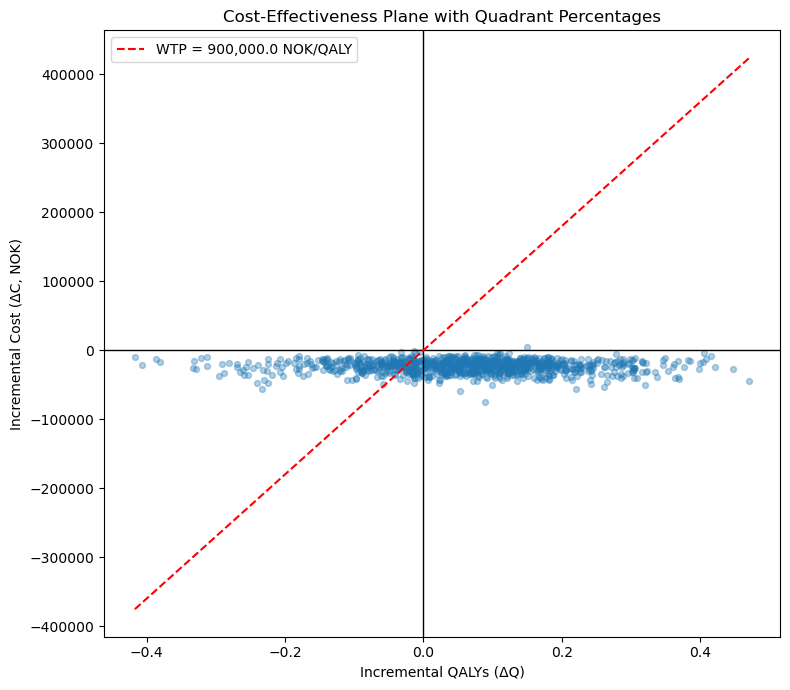

In [72]:
# CE PLOT


plt.figure(figsize=(8,7))

# Axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Scatter
plt.scatter(dQ, dC, alpha=0.35, s=18, color='tab:blue')

# WTP line
q_line = np.linspace(dQ.min(), dQ.max(), 200)
plt.plot(q_line, wtp * q_line, '--', color='red', label=f"WTP = {wtp:,} NOK/QALY")

# Axis labels
plt.xlabel("Incremental QALYs (ΔQ)")
plt.ylabel("Incremental Cost (ΔC, NOK)")
plt.title("Cost-Effectiveness Plane with Quadrant Percentages")


plt.legend()
plt.tight_layout()
plt.show()


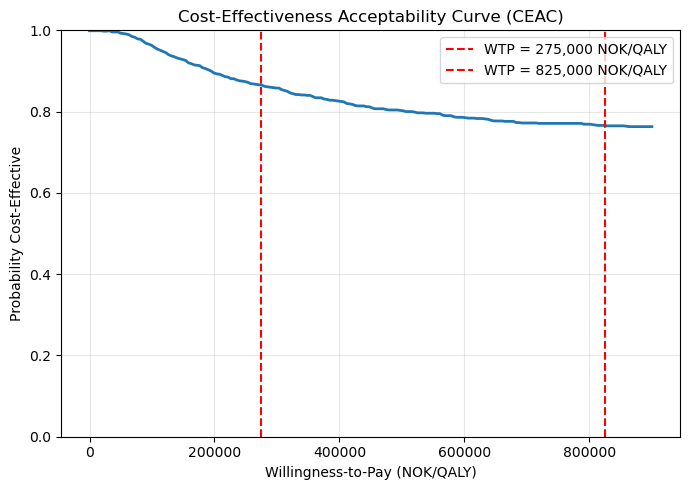

In [73]:
# ============================================
# CEAC
# ============================================

wtp_grid = np.linspace(0, 900000, 200)   # or any range you want

ceac = []

for wtp in wtp_grid:
    # Incremental Net Monetary Benefit
    incr_nmb = wtp * psa_df['dQ'] - psa_df['dC']
    p_ce = np.mean(incr_nmb > 0)
    ceac.append({'WTP': wtp, 'P_CE': p_ce})

ceac_df = pd.DataFrame(ceac)

# Plot CEAC
plt.figure(figsize=(7,5))
plt.plot(ceac_df['WTP'], ceac_df['P_CE'], linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Cost-Effective")
plt.title("Cost-Effectiveness Acceptability Curve (CEAC)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


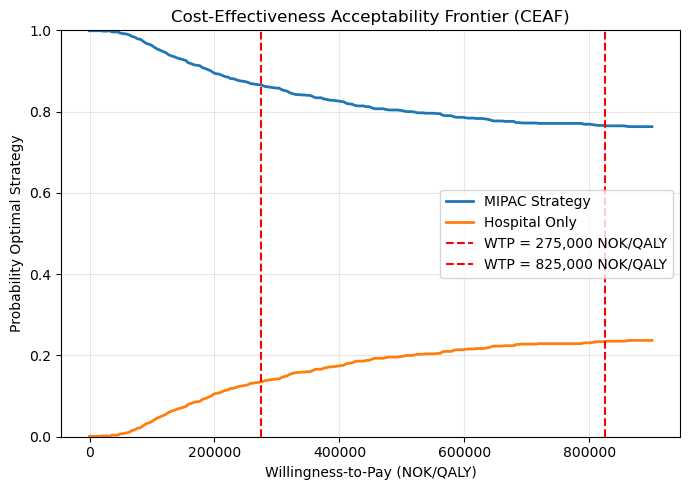

In [74]:
# ============================================
# CEAF
# ============================================

ceaf = []

for wtp in wtp_grid:
    # Net Monetary Benefit for each strategy
    nmb_s = psa_df['qaly_s'] * wtp - psa_df['cost_s']
    nmb_c = psa_df['qaly_c'] * wtp - psa_df['cost_c']

    # Which strategy is optimal in each PSA draw?
    optimal = np.where(nmb_s > nmb_c, 'Strategy', 'Comparator')

    ceaf.append({
        'WTP': wtp,
        'P_opt_strategy': np.mean(optimal == 'Strategy'),
        'P_opt_comparator': np.mean(optimal == 'Comparator')
    })

ceaf_df = pd.DataFrame(ceaf)

# Plot CEAF
plt.figure(figsize=(7,5))
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_strategy'], label="MIPAC Strategy", linewidth=2)
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_comparator'], label="Hospital Only", linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Optimal Strategy")
plt.title("Cost-Effectiveness Acceptability Frontier (CEAF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [75]:
psa_df[['dC','dQ']].describe()


,dC,dQ
count,1000.000000,1000.000000
mean,-23115.728325,0.063660
std,9271.042565,0.136356
min,-75363.447789,-0.416838
25%,-28893.121570,-0.016803
50%,-21923.309889,0.069329
75%,-16326.056702,0.145127
max,4269.365794,0.470768


In [76]:
# Net Monetary Benefit for each strategy

wtp = 275000
psa_df['NMB_s'] = psa_df['qaly_s'] * wtp - psa_df['cost_s']
psa_df['NMB_c'] = psa_df['qaly_c'] * wtp - psa_df['cost_c']

# Incremental NMB
psa_df['INMB'] = psa_df['NMB_s'] - psa_df['NMB_c']

# EVPI per patient
evpi = psa_df[['NMB_s','NMB_c']].max(axis=1).mean() - \
       psa_df[['NMB_s','NMB_c']].mean().max()


print("EVPI per patient:", evpi)


EVPI per patient: 3251.802441834472


In [77]:
## EVPPI for each parameter 

params = [
    'ref_prob_m',
    'mean_costppat_m',
    'qaly_m',
    'cost_epi_h',
    'qaly_h'
]

evppi_results = {}

for p in params:
    X = psa_df[[p]] 
    y = psa_df['INMB'] # this is the observed Incremental net monetary benefit

    model = RandomForestRegressor() ## this regressor is more powerful than a linear regression because it allows the relationship to be more than linear
    model.fit(X, y)

    # Expected INMB with perfect information on this parameter
    evppi = model.predict(X).mean() - y.mean()
    evppi_results[p] = evppi

# Convert to table
evppi_df = pd.DataFrame.from_dict(evppi_results, orient='index', columns=['EVPPI'])
print(evppi_df)


                      EVPPI
ref_prob_m        87.434498
mean_costppat_m  441.790676
qaly_m           238.694202
cost_epi_h       -41.943572
qaly_h          -126.065239
